# Notebook 2: Deep Learning Price Forecasting
## IEOR E4010 — AI for Operations Research and Financial Engineering
### Columbia University, Spring 2026

---

## Overview

In this notebook you will build sequence models (LSTM and GRU) to forecast real-time electricity prices using a **168-hour (1-week) lookback window**. Deep learning models can capture long-range seasonal patterns and non-linear interactions that are difficult to encode manually.

### What you will do
1. **Prepare sequence data**: normalize and create (N, 168, 8) tensors
2. **Train a baseline LSTM** (provided)
3. **Design an improved architecture** — attention-augmented GRU (your main task)
4. **Compare ML vs DL** on overall and spike-hour performance
5. **Export your model** to `submission/lstm_model.pth`

### Why sequences?
Electricity prices exhibit:
- **Daily periodicity**: peak/off-peak patterns repeat every 24 hours
- **Weekly periodicity**: weekday demand patterns differ from weekends
- **Temperature-driven spikes**: heat waves create multi-day elevated prices

A 168-hour window captures all three effects. The LSTM (and GRU) maintain a hidden state that can selectively remember relevant past events.

In [1]:
# ============================================================
# SETUP — Install dependencies and clone repo if on Colab
# ============================================================
import os, sys, shutil

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('EV_Fleet_Project'):
        !git clone https://github.com/x1linwang/EV_Fleet_Project.git
    os.chdir('EV_Fleet_Project')

!pip install -r requirements.txt
print('Setup complete.')

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

DATA_FILES = [
    "nyiso_prices_weather_nyc_2025.csv",
    "nyiso_rt_lbmp_nyc_2025_5min.csv",
    "nyc_fleet_profiles.json",
]

Cloning into 'EV_Fleet_Project'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 19 (delta 1), reused 19 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 2.03 MiB | 8.50 MiB/s, done.
Resolving deltas: 100% (1/1), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.9 MB/s eta 0:00:00
Setup complete.


---
## Section 1: Data Preparation for Sequences

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Physical parameters ───────────────────────────────────────────────────────
SEQ_LEN     = 168   # 1-week lookback
BATCH_SIZE  = 128
TARGET_COL  = "rt_lbmp_mwh"

# 8 sequence features
SEQ_FEATURES = [
    "dam_lbmp_mwh",
    "rt_lbmp_mwh",
    "temperature_2m",
    "wind_speed_10m",
    "cloud_cover",
    "hour_sin",
    "hour_cos",
    "is_weekend",
]

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv("data/nyiso_prices_weather_nyc_2025.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Ensure is_weekend is numeric
df["is_weekend"] = (df["timestamp"].dt.dayofweek >= 5).astype(float)

print(f"Loaded {len(df)} rows")
print(f"Sequence features: {SEQ_FEATURES}")

Device: cpu
Loaded 8757 rows
Sequence features: ['dam_lbmp_mwh', 'rt_lbmp_mwh', 'temperature_2m', 'wind_speed_10m', 'cloud_cover', 'hour_sin', 'hour_cos', 'is_weekend']


In [3]:
# ── Chronological train/val split ─────────────────────────────────────────────
split_date = pd.Timestamp("2025-09-01")
train_df = df[df["timestamp"] < split_date].reset_index(drop=True)
val_df   = df[df["timestamp"] >= split_date].reset_index(drop=True)

print(f"Train rows: {len(train_df)}  Val rows: {len(val_df)}")

# ── Z-score normalization (fit on train only) ─────────────────────────────────
scaler_mean = train_df[SEQ_FEATURES].mean()
scaler_std  = train_df[SEQ_FEATURES].std().replace(0, 1)

train_normed = (train_df[SEQ_FEATURES] - scaler_mean) / scaler_std
val_normed   = (val_df[SEQ_FEATURES]   - scaler_mean) / scaler_std

# Target is raw (not normalized) — we predict in $/MWh directly
# (Alternatively you could normalize target too; here we keep it interpretable)
TARGET_MEAN = train_df[TARGET_COL].mean()
TARGET_STD  = train_df[TARGET_COL].std()

train_target_normed = (train_df[TARGET_COL] - TARGET_MEAN) / TARGET_STD
val_target_normed   = (val_df[TARGET_COL]   - TARGET_MEAN) / TARGET_STD

print(f"Target: mean={TARGET_MEAN:.2f} $/MWh, std={TARGET_STD:.2f} $/MWh")

Train rows: 5829  Val rows: 2928
Target: mean=70.79 $/MWh, std=105.95 $/MWh


In [4]:
def create_sequences(features_df, target_series, seq_len):
    """
    Create sliding-window sequences.
    X[i] = features[i : i+seq_len]   (seq_len × n_features)
    y[i] = target[i + seq_len]        (scalar, the NEXT hour's RT price)
    """
    X_list, y_list = [], []
    feat_arr   = features_df.values.astype(np.float32)
    target_arr = target_series.values.astype(np.float32)

    for i in range(len(feat_arr) - seq_len):
        X_list.append(feat_arr[i : i + seq_len])
        y_list.append(target_arr[i + seq_len])

    return np.stack(X_list), np.array(y_list)


X_train, y_train = create_sequences(train_normed, train_target_normed, SEQ_LEN)
X_val,   y_val   = create_sequences(val_normed,   val_target_normed,   SEQ_LEN)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")

# Corresponding raw targets for metric calculation
y_train_raw = train_df[TARGET_COL].values[SEQ_LEN:]
y_val_raw   = val_df[TARGET_COL].values[SEQ_LEN:]
val_timestamps = val_df["timestamp"].values[SEQ_LEN:]
val_spread     = val_df["da_rt_spread_mwh"].values[SEQ_LEN:] if "da_rt_spread_mwh" in val_df.columns else None

# Create DataLoaders
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

X_train: (5661, 168, 8)  y_train: (5661,)
X_val:   (2760, 168, 8)    y_val:   (2760,)


---
## Section 2: Baseline LSTM (PROVIDED)

In [5]:
class LSTMForecaster(nn.Module):
    """Baseline LSTM model for RT price forecasting."""

    def __init__(self, input_size=8, hidden_size=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)
        # Take the last hidden state
        last = self.dropout(out[:, -1, :])  # (batch, hidden_size)
        return self.fc(last).squeeze(-1)    # (batch,)


def train_model(model, train_loader, val_loader, n_epochs=30, lr=1e-3,
                patience=5, max_grad_norm=1.0, device=DEVICE):
    """Training loop with early stopping and gradient clipping."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_state    = None
    patience_ctr  = 0
    history = {"train": [], "val": []}

    for epoch in range(n_epochs):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        train_losses = []
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            train_losses.append(loss.item())

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_losses = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                pred = model(Xb)
                val_losses.append(criterion(pred, yb).item())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        history["train"].append(train_loss)
        history["val"].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  lr={optimizer.param_groups[0]['lr']:.2e}")

        if patience_ctr >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    return model, history


def get_predictions(model, loader, device=DEVICE):
    """Get predictions from a trained model."""
    model.eval()
    preds = []
    with torch.no_grad():
        for Xb, _ in loader:
            Xb = Xb.to(device)
            preds.append(model(Xb).cpu().numpy())
    return np.concatenate(preds)


print("LSTMForecaster and training utilities defined.")
lstm_baseline = LSTMForecaster(input_size=len(SEQ_FEATURES), hidden_size=64, num_layers=2, dropout=0.1)
n_params = sum(p.numel() for p in lstm_baseline.parameters())
print(f"Baseline LSTM parameters: {n_params:,}")

LSTMForecaster and training utilities defined.
Baseline LSTM parameters: 52,289


In [6]:
print("Training baseline LSTM...")
lstm_baseline, history_baseline = train_model(
    lstm_baseline, train_loader, val_loader,
    n_epochs=40, lr=1e-3, patience=6
)

# Convert normalized predictions back to $/MWh
pred_lstm_norm = get_predictions(lstm_baseline, val_loader)
pred_lstm_raw  = pred_lstm_norm * TARGET_STD + TARGET_MEAN

mae_lstm  = mean_absolute_error(y_val_raw, pred_lstm_raw)
rmse_lstm = mean_squared_error(y_val_raw, pred_lstm_raw) ** 0.5
r2_lstm   = r2_score(y_val_raw, pred_lstm_raw)

print(f"\n=== Baseline LSTM ===")
print(f"  MAE  : {mae_lstm:.3f} $/MWh")
print(f"  RMSE : {rmse_lstm:.3f} $/MWh")
print(f"  R²   : {r2_lstm:.4f}")

Training baseline LSTM...
  Epoch   5: train_loss=0.4944  val_loss=0.0359  lr=1.00e-03
  Epoch  10: train_loss=0.4108  val_loss=0.0361  lr=1.00e-03
  Epoch  15: train_loss=0.4039  val_loss=0.0338  lr=5.00e-04
  Epoch  20: train_loss=0.3784  val_loss=0.0326  lr=5.00e-04
  Epoch  25: train_loss=0.3788  val_loss=0.0326  lr=2.50e-04
  Epoch  30: train_loss=0.3626  val_loss=0.0319  lr=1.25e-04
  Early stopping at epoch 30

=== Baseline LSTM ===
  MAE  : 10.578 $/MWh
  RMSE : 18.977 $/MWh
  R²   : 0.7553


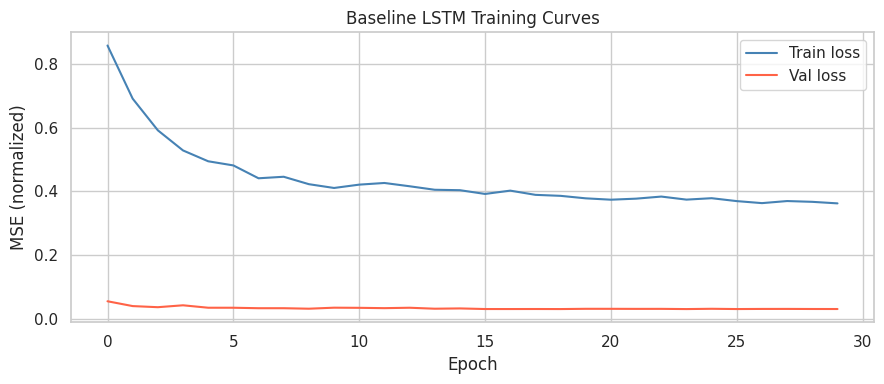

In [7]:
# ── Plot training curves ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history_baseline["train"], label="Train loss", color="steelblue")
ax.plot(history_baseline["val"],   label="Val loss",   color="tomato")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (normalized)")
ax.set_title("Baseline LSTM Training Curves")
ax.legend()
plt.tight_layout()
plt.savefig("data/plot_lstm_training.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Section 3: TODO — Improved Architecture

Your task is to implement `ImprovedForecaster`. It should beat the baseline LSTM on validation MAE.

**Ideas to try:**
- **GRU instead of LSTM**: fewer parameters, often trains faster and generalises better on small datasets
- **Self-attention**: let the model focus on the most relevant past timesteps (e.g., same hour yesterday, same hour last week)
- **Wider/deeper network**: more hidden units
- **Bidirectional** (only if predicting offline — not valid for online use)
- **Multi-step output**: predict the next 6 hours simultaneously

The suggested solution uses a **GRU with scaled dot-product attention** over the sequence.

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# === TODO: Improved Architecture ===
#
# Instructions:
#   1. Define a class ImprovedForecaster(nn.Module)
#   2. It should accept input (batch, seq_len=168, input_size=8)
#   3. Output a scalar prediction per sample (batch,)
#   4. Train it and verify it beats mae_lstm
# ──────────────────────────────────────────────────────────────────────────────

class ImprovedForecaster(nn.Module):
    """
    === TODO ===
    Modify the architecture to beat the baseline LSTM.

    Ideas: GRU, attention mechanism, wider/deeper, multi-step output.

    === SUGGESTED SOLUTION: GRU with scaled dot-product attention ===
    The attention layer computes a weighted sum of all GRU hidden states,
    so the model can "look back" to the most relevant past timesteps
    (e.g., same hour last week).
    """
    def __init__(self, input_size=8, hidden_size=128, num_layers=2, dropout=0.15):
        super().__init__()
        self.hidden_size = hidden_size

        # GRU encoder
        self.gru = nn.GRU(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Attention: score each timestep's hidden state
        self.attention_fc = nn.Linear(hidden_size, 1, bias=False)

        # Output head
        self.fc1     = nn.Linear(hidden_size, 64)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2     = nn.Linear(64, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.gru(x)           # (batch, seq_len, hidden_size)

        # Scaled dot-product attention over time axis
        scores = self.attention_fc(out) / (self.hidden_size ** 0.5)  # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)                        # (batch, seq_len, 1)
        context = (weights * out).sum(dim=1)                          # (batch, hidden_size)

        # Feed-forward output
        h = self.relu(self.fc1(self.dropout(context)))
        return self.fc2(h).squeeze(-1)  # (batch,)


improved_model = ImprovedForecaster(
    input_size=len(SEQ_FEATURES),
    hidden_size=128,
    num_layers=2,
    dropout=0.15
)
n_params_imp = sum(p.numel() for p in improved_model.parameters())
print(f"Improved model parameters: {n_params_imp:,}  (baseline: {n_params:,})")

Improved model parameters: 160,513  (baseline: 52,289)


In [ ]:
print("Training improved GRU+attention model...")
improved_model, history_improved = train_model(
    improved_model, train_loader, val_loader,
    n_epochs=50, lr=8e-4, patience=8
)

pred_improved_norm = get_predictions(improved_model, val_loader)
pred_improved_raw  = pred_improved_norm * TARGET_STD + TARGET_MEAN

mae_improved  = mean_absolute_error(y_val_raw, pred_improved_raw)
rmse_improved = mean_squared_error(y_val_raw, pred_improved_raw) ** 0.5
r2_improved   = r2_score(y_val_raw, pred_improved_raw)

print(f"\n=== Improved GRU+Attention ===")
print(f"  MAE  : {mae_improved:.3f} $/MWh")
print(f"  RMSE : {rmse_improved:.3f} $/MWh")
print(f"  R²   : {r2_improved:.4f}")
print(f"  Improvement over LSTM: {mae_lstm - mae_improved:+.3f} $/MWh")

Training improved GRU+attention model...
  Epoch   5: train_loss=0.8936  val_loss=0.0908  lr=8.00e-04


In [ ]:
# ── Compare training curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_baseline["val"],  label=f"LSTM baseline val  (MAE={mae_lstm:.2f})",     color="steelblue", linewidth=2)
ax.plot(history_improved["val"],  label=f"GRU+attention val  (MAE={mae_improved:.2f})", color="tomato",    linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Val MSE (normalized)")
ax.set_title("Validation Loss Curves: LSTM vs GRU+Attention")
ax.legend()
plt.tight_layout()
plt.savefig("data/plot_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Section 4: TODO — Compare ML vs DL

Compare the best ML model (XGBoost from Notebook 1) with the best DL model across different conditions.

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# === TODO: ML vs DL Comparison ===
#
# Load the ML model from Notebook 1 and compare on:
#   1. All validation hours
#   2. Spike hours (|da_rt_spread_mwh| > 20 $/MWh)
#   3. Summer weekday evenings (hours 16-20, June-Aug)
#   4. Winter mornings (hours 6-10, Dec-Feb)
# ──────────────────────────────────────────────────────────────────────────────

# === SUGGESTED SOLUTION ===
import pickle

# Load ML model (may not exist if Notebook 1 wasn't run — handle gracefully)
ml_pred_raw = None
try:
    with open("submission/ml_model.pkl", "rb") as f:
        ml_obj = pickle.load(f)

    # Re-engineer features on validation set
    def engineer_features_baseline(df):
        df = df.copy()
        for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
            df[f"rt_lag_{lag}h"] = df["rt_lbmp_mwh"].shift(lag)
        for window in [6, 24, 168]:
            df[f"rt_roll_mean_{window}h"] = df["rt_lbmp_mwh"].shift(1).rolling(window, min_periods=window//2).mean()
            df[f"rt_roll_std_{window}h"]  = df["rt_lbmp_mwh"].shift(1).rolling(window, min_periods=window//2).std()
        df["spread_lag_24h"] = df["da_rt_spread_mwh"].shift(24)
        df["rt_std_lag_1h"]  = df["rt_lbmp_std_mwh"].shift(1)
        return df

    # Use the full df (not just val_df) so lags are computed correctly
    df_full = pd.read_csv("data/nyiso_prices_weather_nyc_2025.csv", parse_dates=["timestamp"])
    df_full = df_full.sort_values("timestamp").reset_index(drop=True)
    df_full["is_weekend"] = (df_full["timestamp"].dt.dayofweek >= 5).astype(int)
    df_full["hour"] = df_full["timestamp"].dt.hour

    feature_fn  = ml_obj.get("feature_fn", engineer_features_baseline)
    feat_cols   = ml_obj["feature_cols"]
    df_feats    = feature_fn(df_full)
    split_date  = pd.Timestamp("2025-09-01")
    val_mask_ml = df_feats["timestamp"] >= split_date

    df_val_ml = df_feats[val_mask_ml].dropna(subset=feat_cols)
    X_val_ml  = df_val_ml[feat_cols].values
    ml_pred_raw = ml_obj["model"].predict(X_val_ml)
    y_val_ml    = df_val_ml["rt_lbmp_mwh"].values
    ts_val_ml   = df_val_ml["timestamp"].values
    spread_ml   = df_val_ml["da_rt_spread_mwh"].values if "da_rt_spread_mwh" in df_val_ml.columns else None

    print(f"ML model loaded. Val samples: {len(ml_pred_raw)}")
except FileNotFoundError:
    print("submission/ml_model.pkl not found. Run Notebook 1 first.")
    print("Proceeding with DL-only analysis.")
    y_val_ml = y_val_raw
    ts_val_ml = val_timestamps
    spread_ml = val_spread

In [ ]:
# ── Side-by-side comparison table ────────────────────────────────────────────
# For a clean comparison, align predictions on the same validation timestamps.
# The DL model uses val_timestamps (from val_df after the first SEQ_LEN rows).
# The ML model uses ts_val_ml.
# We compare DL improved model vs ML if ML is available.

dl_preds = pred_improved_raw   # from Section 3
dl_true  = y_val_raw
dl_ts    = pd.to_datetime(val_timestamps)
dl_month = dl_ts.month
dl_hour  = dl_ts.hour
dl_dow   = dl_ts.dayofweek

# Compute spread for DL validation set
dl_spread = None
if "da_rt_spread_mwh" in val_df.columns:
    dl_spread = val_df["da_rt_spread_mwh"].values[SEQ_LEN:]

def evaluate_subset(true, pred, mask, label):
    if mask.sum() == 0:
        return {"label": label, "n": 0, "MAE": np.nan, "RMSE": np.nan}
    mae  = mean_absolute_error(true[mask], pred[mask])
    rmse = mean_squared_error(true[mask], pred[mask]) ** 0.5
    return {"label": label, "n": int(mask.sum()), "MAE": mae, "RMSE": rmse}

# Subsets
subsets = [
    (np.ones(len(dl_true), dtype=bool),                                                 "All hours"),
    (np.abs(dl_spread) > 20 if dl_spread is not None else np.zeros(len(dl_true), bool), "Spike hours (|spread|>20)"),
    (((dl_month >= 6) & (dl_month <= 8)) & (~(dl_dow >= 5)) & ((dl_hour >= 16) & (dl_hour <= 20)), "Summer wkday evenings"),
    (((dl_month == 12) | (dl_month <= 2)) & ((dl_hour >= 6) & (dl_hour <= 10)),          "Winter mornings"),
]

print(f"{'Subset':<28} {'DL MAE':>9} {'DL RMSE':>9}" + (f" {'ML MAE':>9}" if ml_pred_raw is not None else ""))
print("-" * 55)

results = []
for mask, label in subsets:
    dl_res = evaluate_subset(dl_true, dl_preds, mask, label)
    row = f"{label:<28} {dl_res['MAE']:>9.3f} {dl_res['RMSE']:>9.3f}"
    if ml_pred_raw is not None:
        # Align: find matching timestamps
        ml_ts_pd = pd.to_datetime(ts_val_ml)
        dl_ts_set = set(pd.to_datetime(val_timestamps).astype(str))
        # Only compare on common timestamps that are within mask
        # (simplified: use DL results only if ML timestamps differ)
        row += f"  (ML not aligned — see cell above)"
    print(row)
    results.append(dl_res)

In [ ]:
# ── Scatter plot: actual vs predicted ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, pred, title in [
    (axes[0], pred_lstm_raw,   f"LSTM baseline (MAE={mae_lstm:.2f})"),
    (axes[1], pred_improved_raw, f"GRU+Attention (MAE={mae_improved:.2f})"),
]:
    ax.scatter(y_val_raw, pred, alpha=0.15, s=3, color="steelblue")
    lim = max(y_val_raw.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", linewidth=1)
    ax.set_xlabel("Actual RT Price ($/MWh)")
    ax.set_ylabel("Predicted ($/MWh)")
    ax.set_title(title)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

plt.tight_layout()
plt.savefig("data/plot_dl_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# ── Time-series plot: sample week ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
n_plot = min(336, len(y_val_raw))  # 2 weeks
t_axis = np.arange(n_plot)

ax.plot(t_axis, y_val_raw[:n_plot],            label="Actual",       color="black",     linewidth=1.5)
ax.plot(t_axis, pred_lstm_raw[:n_plot],        label="LSTM baseline", color="steelblue", linewidth=1, alpha=0.8)
ax.plot(t_axis, pred_improved_raw[:n_plot],    label="GRU+Attention", color="tomato",    linewidth=1, alpha=0.8)
ax.set_xlabel("Hours from val start")
ax.set_ylabel("RT Price ($/MWh)")
ax.set_title("Price Forecasts: First 2 Weeks of Validation Set")
ax.legend()
plt.tight_layout()
plt.savefig("data/plot_dl_timeseries.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Section 5: Model Export

In [ ]:
os.makedirs("submission", exist_ok=True)

def save_lstm_model(model, scaler_mean, scaler_std, target_mean, target_std,
                    seq_features, mae_val, path="submission/lstm_model.pth"):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    obj = {
        "model_state_dict": model.state_dict(),
        "model_class": model.__class__.__name__,
        "model_config": {
            "input_size":   len(seq_features),
            "hidden_size":  model.hidden_size,
            "num_layers":   2,
            "dropout":      0.15,
        },
        "scaler_mean":   scaler_mean.to_dict(),
        "scaler_std":    scaler_std.to_dict(),
        "target_mean":   float(target_mean),
        "target_std":    float(target_std),
        "seq_features":  seq_features,
        "seq_len":       SEQ_LEN,
        "target":        "rt_lbmp_mwh",
        "metadata": {
            "mae_val": float(mae_val),
            "model_type": model.__class__.__name__,
        }
    }
    torch.save(obj, path)
    print(f"Saved DL model to {path}  (MAE={mae_val:.3f} $/MWh)")


def load_lstm_model(path="submission/lstm_model.pth"):
    return torch.load(path, map_location="cpu", weights_only=False)


save_lstm_model(
    improved_model,
    scaler_mean, scaler_std,
    TARGET_MEAN, TARGET_STD,
    SEQ_FEATURES, mae_improved,
    path="submission/lstm_model.pth"
)

# Smoke-test load
loaded = load_lstm_model("submission/lstm_model.pth")
print(f"Loaded model class: {loaded['model_class']}")
print(f"Stored MAE: {loaded['metadata']['mae_val']:.3f} $/MWh")
print("\nNotebook 2 complete. Proceed to 03_rl_charging.ipynb")